Below code, calculates the age of each frame

In [29]:
import pandas as pd

df = pd.read_csv("crossing_evidence.csv")

# Calculate message age
df["message_age"] = df["time_s"] - df["v2x_sample_time_s"]

# Select required columns
output = df[["frame", "v2x_light", "red_score", "message_age"]]

# Show ALL 72 rows
print(output.to_string(index=False))

 frame v2x_light  red_score  message_age
     0     green      0.010          0.0
     1     green      0.010          0.0
     2     green      0.028          0.0
     3     green      0.010          0.0
     4     green      0.040          0.0
     5     green      0.010          0.5
     6     green      0.365          0.6
     7     green      0.094          0.0
     8     green      0.010          0.0
     9     green      0.160          0.0
    10     green      0.010          0.0
    11     green      0.241          0.0
    12     green      0.049          0.6
    13     green      0.010          0.6
    14     green      0.111          0.0
    15     green      0.070          0.0
    16     green      0.149          0.0
    17     green      0.010          0.0
    18     green      0.155          0.0
    19     green      0.010          0.6
    20     green      0.010          0.6
    21     green      0.318          0.0
    22     green      0.010          0.0
    23     green

Now we find out, for which frame, v2x gives misleading results.
i.e. green, even though from red score we get STOP

In [30]:
import pandas as pd

df = pd.read_csv("crossing_evidence.csv")

# Calculate V2X message age
df["message_age"] = df["time_s"] - df["v2x_sample_time_s"]

# Find misleading frames:
# red_score says STOP, but V2X still says GREEN
misleading = df[
    (df["red_score"] > 0.8) &
    (df["v2x_light"].str.lower() == "green")
]

# Show all relevant information
print(misleading[
    ["episode", "frame", "time_s", "red_score",
     "v2x_light", "v2x_sample_time_s", "message_age"]
].to_string(index=False))

 episode  frame  time_s  red_score v2x_light  v2x_sample_time_s  message_age
late_red     12     1.2      0.911     green                0.6          0.6
late_red     13     1.3      0.987     green                0.7          0.6


## Revised Decision Logic

The revised decision system keeps the original **STOP → SLOW → GO** priority structure, with one exception: **uncertain image-based person detection is checked before the remaining STOP conditions**.

### 1. Image-Based Person Evidence

The image-derived person score is checked first:

- `image_person_score > 0.8` → **STOP**
  - Strong visual evidence that the person is on the road.
- `0.5 ≤ image_person_score ≤ 0.8` → **SLOW**
  - A person is detected, but road occupancy is uncertain.
  - This is the **only SLOW condition evaluated before the remaining STOP conditions**.

### 2. Remaining STOP Conditions

After the image check, all stronger evidence is evaluated before considering the remaining SLOW conditions.

- `person_score > 0.8` → **STOP**
- If the V2X message is **fresh** (`message_age ≤ 0.5 s`) and reports **RED** → **STOP**
- If the V2X message is **stale** (`message_age > 0.5 s`) but the current `red_score > 0.8` → **STOP**

The key change is that a stale V2X message is **not trusted as current information**. Instead, the current visual `red_score` is used to determine whether the vehicle should stop.

### 3. Remaining SLOW Conditions

Only after all STOP conditions have been checked:

- `0.5 ≤ person_score ≤ 0.8` → **SLOW**
- Fresh V2X is GREEN but `0.5 ≤ red_score ≤ 0.8` → **SLOW**
- Fresh V2X is GREEN but `red_score > 0.8` → **SLOW**
- Stale V2X with `0.5 ≤ red_score ≤ 0.8` → **SLOW**

### 4. GO

If none of the above conditions are satisfied:

- → **GO**

### Message Age

The age of the V2X message is calculated as:

\[
\text{message\_age}
=
\text{time}_s-\text{v2x\_sample\_time}_s
\]

A threshold of **0.5 s** is used to distinguish fresh and stale V2X information.

This revision makes the system explicitly account for **communication delay and stale V2X information**, rather than treating every received V2X state as equally current.


PERSON CROSSING — REVISED DECISION TIMELINE
Frame 00 | t=0.00s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | age=0.00s | GO   | No strong person/red/V2X evidence
Frame 01 | t=0.10s | person=0.113 | image_person=0.0 | red=0.010 | V2X=green | age=0.00s | GO   | No strong person/red/V2X evidence
Frame 02 | t=0.20s | person=0.010 | image_person=0.0 | red=0.028 | V2X=green | age=0.00s | GO   | No strong person/red/V2X evidence
Frame 03 | t=0.30s | person=0.153 | image_person=0.0 | red=0.010 | V2X=green | age=0.00s | GO   | No strong person/red/V2X evidence
Frame 04 | t=0.40s | person=0.456 | image_person=0.0 | red=0.040 | V2X=green | age=0.00s | GO   | No strong person/red/V2X evidence
Frame 05 | t=0.50s | person=0.219 | image_person=0.0 | red=0.010 | V2X=green | age=0.50s | GO   | No strong person/red/V2X evidence
Frame 06 | t=0.60s | person=0.770 | image_person=0.0 | red=0.365 | V2X=green | age=0.60s | SLOW | Moderate person_score
Frame 07 | t=0.70s | person=0.770 | image_p

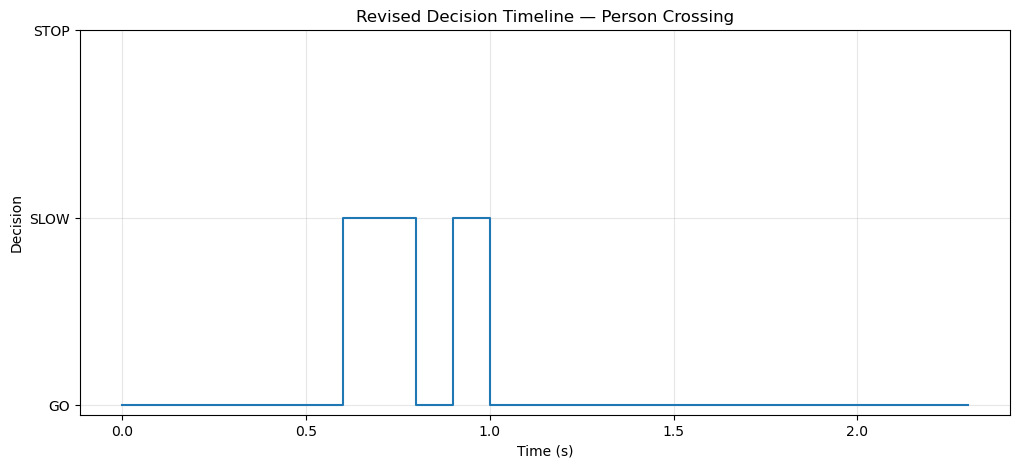

In [37]:
import cv2
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt


# ============================================================
# 1. IMAGE-BASED PERSON SCORE
# ============================================================

def get_image_person_score(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return 0.0

    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --------------------------------------------------------
    # Check row v = 235
    # --------------------------------------------------------

    v = 235
    row = img[v]

    # Brightness = R + G + B
    brightness = np.sum(row[:, :3], axis=1)

    # --------------------------------------------------------
    # Detect black pixels
    # --------------------------------------------------------

    # Black-pixel threshold = 150
    black_pixels = np.where(brightness <= 150)[0]

    # --------------------------------------------------------
    # Group nearby black pixels
    # --------------------------------------------------------

    groups = []

    if len(black_pixels) > 0:

        current_group = [black_pixels[0]]

        for i in range(1, len(black_pixels)):

            # Pixels within 3 positions are considered
            # part of the same group
            if black_pixels[i] - black_pixels[i - 1] <= 3:

                current_group.append(black_pixels[i])

            else:

                if len(current_group) >= 2:
                    groups.append(current_group)

                current_group = [black_pixels[i]]

        # Add final group
        if len(current_group) >= 2:
            groups.append(current_group)

    # --------------------------------------------------------
    # Need two groups = two legs
    # --------------------------------------------------------

    if len(groups) < 2:

        return 0.0

    # Take two largest groups
    groups = sorted(
        groups,
        key=len,
        reverse=True
    )[:2]

    # Sort groups from left → right
    groups = sorted(
        groups,
        key=lambda g: np.mean(g)
    )

    left_leg = groups[0]
    right_leg = groups[1]

    # Rightmost pixel of right leg
    right_leg_rightmost = max(right_leg)

    # --------------------------------------------------------
    # Detect RIGHT ROAD BOUNDARY
    # --------------------------------------------------------

    max_brightness = np.max(brightness)

    # Road-boundary brightness threshold = 650
    if max_brightness < 650:

        # No right boundary detected.
        # Since two legs are detected, conclude
        # that the person is on the road.

        return 1.0

    # --------------------------------------------------------
    # Find LEFT and RIGHT road boundaries
    # --------------------------------------------------------

    brightest_pixels = np.where(
        brightness == max_brightness
    )[0]

    # Leftmost brightest pixel = left boundary
    left_boundary = np.min(brightest_pixels)

    # Rightmost brightest pixel = right boundary
    right_boundary = np.max(brightest_pixels)

    # --------------------------------------------------------
    # Check minimum gap between road boundaries
    # --------------------------------------------------------

    boundary_gap = right_boundary - left_boundary

    if boundary_gap < 10:

        # Boundaries are too close to be considered
        # a valid road boundary pair.
        #
        # Therefore the right boundary is treated
        # as NOT detected.

        return 1.0

    # --------------------------------------------------------
    # Determine whether person is on road
    # --------------------------------------------------------

    if right_leg_rightmost < right_boundary:

        # Person is inside the road
        return 1.0

    else:

        # Person detected but road occupancy is uncertain
        return 0.5


# ============================================================
# 2. REVISED DECISION LOGIC
# ============================================================

def revised_decision(
    person_score,
    image_person_score,
    red_score,
    v2x_light,
    message_age
):

    # ========================================================
    # EXCEPTION:
    # IMAGE PERSON SCORE IS CHECKED FIRST
    # ========================================================

    # Strong image evidence → STOP
    if image_person_score > 0.8:

        return "STOP", "Image confirms person is on road"

    # Uncertain image evidence → SLOW
    # This is the ONLY SLOW condition checked before
    # the remaining STOP conditions.
    if 0.5 <= image_person_score <= 0.8:

        return "SLOW", (
            "Person detected but road occupancy uncertain"
        )


    # ========================================================
    # STEP 1 — ALL REMAINING STOP CONDITIONS
    # ========================================================

    # Strong secondary person evidence
    if person_score > 0.8:

        return "STOP", "High person_score"


    # --------------------------------------------------------
    # V2X DECISION
    # --------------------------------------------------------

    # Fresh V2X message
    if message_age <= 0.5:

        # Fresh RED → STOP
        if str(v2x_light).lower() == "red":

            return "STOP", "Fresh V2X reports red"


    # Stale V2X message
    else:

        # If stale V2X and strong current red evidence
        # → STOP regardless of old V2X state
        if red_score > 0.8:

            return "STOP", (
                "V2X message is stale; high red_score"
            )


    # ========================================================
    # STEP 2 — ALL SLOW CONDITIONS
    # ========================================================

    # Moderate person evidence
    if 0.5 <= person_score <= 0.8:

        return "SLOW", "Moderate person_score"


    # --------------------------------------------------------
    # V2X + RED SCORE SLOW CONDITIONS
    # --------------------------------------------------------

    # Fresh V2X
    if message_age <= 0.5:

        # Fresh GREEN but camera sees strong red evidence
        if str(v2x_light).lower() == "green":

            if red_score > 0.8:

                return "SLOW", (
                    "Fresh V2X is green but red_score is high"
                )

            if 0.5 <= red_score <= 0.8:

                return "SLOW", (
                    "Fresh V2X is green but red_score is moderate"
                )


    # Stale V2X
    else:

        # Moderate red evidence → SLOW
        if 0.5 <= red_score <= 0.8:

            return "SLOW", (
                "V2X message is stale; moderate red_score"
            )


    # Moderate red evidence in general
    if 0.5 <= red_score <= 0.8:

        return "SLOW", "Moderate red_score"


    # ========================================================
    # STEP 3 — GO
    # ========================================================

    return "GO", "No strong person/red/V2X evidence"
# ============================================================
# 3. LOAD CROSSING EVIDENCE
# ============================================================

evidence_path = "crossing_evidence.csv"

evidence = pd.read_csv(evidence_path)


# ============================================================
# 4. CALCULATE V2X MESSAGE AGE
# ============================================================

evidence["message_age"] = (
    evidence["time_s"] -
    evidence["v2x_sample_time_s"]
)


# ============================================================
# 5. LOAD PERSON-CROSSING IMAGES
# ============================================================

image_files = sorted(
    glob.glob("clear_green/*.png"),
    key=lambda x: int(
        os.path.splitext(
            os.path.basename(x)
        )[0].split("_")[-1]
    )
)


# ============================================================
# 6. PROCESS ALL FRAMES
# ============================================================

results = []

for image_path in image_files:

    filename = os.path.basename(image_path)

    # Extract frame number
    frame_number = int(
        os.path.splitext(filename)[0].split("_")[-1]
    )

    # --------------------------------------------------------
    # Find corresponding evidence row
    # --------------------------------------------------------

    row = evidence[
        (evidence["episode"] == "clear_green") &
        (evidence["frame"] == frame_number)
    ]

    if len(row) == 0:

        print("No evidence found for:", filename)
        continue

    row = row.iloc[0]

    # --------------------------------------------------------
    # CSV evidence
    # --------------------------------------------------------

    time_s = row["time_s"]

    person_score = row["person_score"]

    red_score = row["red_score"]

    v2x_light = row["v2x_light"]

    message_age = row["message_age"]


    # --------------------------------------------------------
    # Calculate image-based person score
    # --------------------------------------------------------

    image_person_score = get_image_person_score(
        image_path
    )


    # --------------------------------------------------------
    # Apply revised decision
    # --------------------------------------------------------

    decision, reason = revised_decision(
        person_score,
        image_person_score,
        red_score,
        v2x_light,
        message_age
    )


    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    results.append({

        "frame": frame_number,

        "time_s": time_s,

        "person_score": person_score,

        "image_person_score": image_person_score,

        "red_score": red_score,

        "v2x_light": v2x_light,

        "message_age": message_age,

        "decision": decision,

        "reason": reason
    })


# ============================================================
# 7. CREATE RESULTS DATAFRAME
# ============================================================

results_df1 = pd.DataFrame(results)


# ============================================================
# 8. PRINT FULL TIMELINE
# ============================================================

print("\n" + "=" * 120)

print(
    "PERSON CROSSING — REVISED DECISION TIMELINE"
)

print("=" * 120)

for _, r in results_df1.iterrows():

    print(
        f"Frame {int(r['frame']):02d} | "
        f"t={r['time_s']:.2f}s | "
        f"person={r['person_score']:.3f} | "
        f"image_person={r['image_person_score']:.1f} | "
        f"red={r['red_score']:.3f} | "
        f"V2X={r['v2x_light']} | "
        f"age={r['message_age']:.2f}s | "
        f"{r['decision']:4s} | "
        f"{r['reason']}"
    )


# ============================================================
# 9. PRINT COMPACT TIMELINE
# ============================================================

print("\n")
print("COMPACT TIMELINE")
print("-" * 70)

for _, r in results_df1.iterrows():

    print(
        f"Frame {int(r['frame']):02d} "
        f"(t={r['time_s']:.2f}s) → "
        f"{r['decision']}"
    )


# ============================================================
# 10. PLOT DECISION TIMELINE
# ============================================================

decision_value = {
    "GO": 0,
    "SLOW": 1,
    "STOP": 2
}

y = results_df1["decision"].map(
    decision_value
)

plt.figure(figsize=(12, 5))

plt.step(
    results_df1["time_s"],
    y,
    where="post"
)

plt.yticks(
    [0, 1, 2],
    ["GO", "SLOW", "STOP"]
)

plt.xlabel("Time (s)")
plt.ylabel("Decision")

plt.title(
    "Revised Decision Timeline — Person Crossing"
)

plt.grid(True, alpha=0.3)

plt.show()



PERSON CROSSING — REVISED DECISION TIMELINE
Frame 00 | t=0.00s | person=0.146 | image_person=0.0 | red=0.090 | V2X=green | age=0.00s | GO   | No strong person/red/V2X evidence
Frame 01 | t=0.10s | person=0.541 | image_person=0.0 | red=0.010 | V2X=green | age=0.00s | SLOW | Moderate person_score
Frame 02 | t=0.20s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | age=0.00s | GO   | No strong person/red/V2X evidence
Frame 03 | t=0.30s | person=0.335 | image_person=0.0 | red=0.017 | V2X=green | age=0.00s | GO   | No strong person/red/V2X evidence
Frame 04 | t=0.40s | person=0.078 | image_person=0.0 | red=0.108 | V2X=green | age=0.00s | GO   | No strong person/red/V2X evidence
Frame 05 | t=0.50s | person=0.192 | image_person=0.0 | red=0.078 | V2X=green | age=0.50s | GO   | No strong person/red/V2X evidence
Frame 06 | t=0.60s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | age=0.60s | GO   | No strong person/red/V2X evidence
Frame 07 | t=0.70s | person=0.010 | image_p

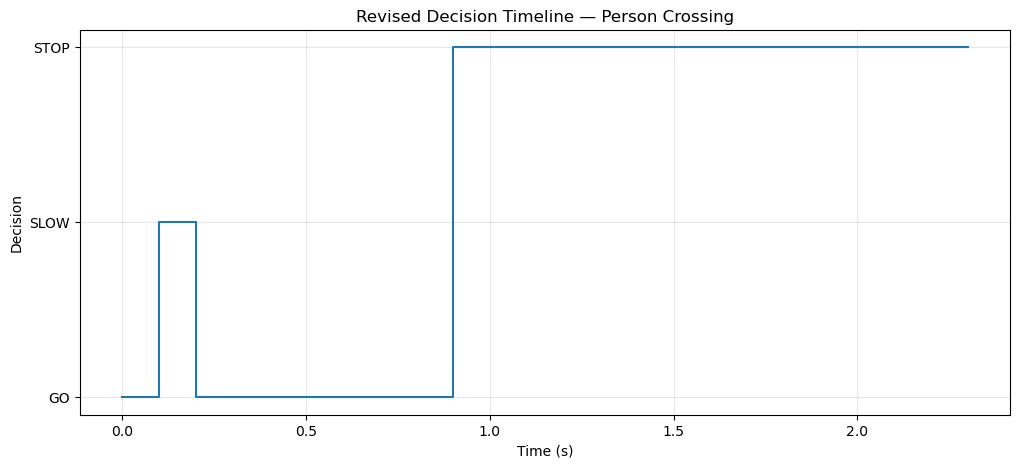

In [38]:

import cv2
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt


# ============================================================
# 1. IMAGE-BASED PERSON SCORE
# ============================================================

def get_image_person_score(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return 0.0

    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --------------------------------------------------------
    # Check row v = 235
    # --------------------------------------------------------

    v = 235
    row = img[v]

    # Brightness = R + G + B
    brightness = np.sum(row[:, :3], axis=1)

    # --------------------------------------------------------
    # Detect black pixels
    # --------------------------------------------------------

    # Black-pixel threshold = 150
    black_pixels = np.where(brightness <= 150)[0]

    # --------------------------------------------------------
    # Group nearby black pixels
    # --------------------------------------------------------

    groups = []

    if len(black_pixels) > 0:

        current_group = [black_pixels[0]]

        for i in range(1, len(black_pixels)):

            # Pixels within 3 positions are considered
            # part of the same group
            if black_pixels[i] - black_pixels[i - 1] <= 3:

                current_group.append(black_pixels[i])

            else:

                if len(current_group) >= 2:
                    groups.append(current_group)

                current_group = [black_pixels[i]]

        # Add final group
        if len(current_group) >= 2:
            groups.append(current_group)

    # --------------------------------------------------------
    # Need two groups = two legs
    # --------------------------------------------------------

    if len(groups) < 2:

        return 0.0

    # Take two largest groups
    groups = sorted(
        groups,
        key=len,
        reverse=True
    )[:2]

    # Sort groups from left → right
    groups = sorted(
        groups,
        key=lambda g: np.mean(g)
    )

    left_leg = groups[0]
    right_leg = groups[1]

    # Rightmost pixel of right leg
    right_leg_rightmost = max(right_leg)

    # --------------------------------------------------------
    # Detect RIGHT ROAD BOUNDARY
    # --------------------------------------------------------

    max_brightness = np.max(brightness)

    # Road-boundary brightness threshold = 650
    if max_brightness < 650:

        # No right boundary detected.
        # Since two legs are detected, conclude
        # that the person is on the road.

        return 1.0

    # --------------------------------------------------------
    # Find LEFT and RIGHT road boundaries
    # --------------------------------------------------------

    brightest_pixels = np.where(
        brightness == max_brightness
    )[0]

    # Leftmost brightest pixel = left boundary
    left_boundary = np.min(brightest_pixels)

    # Rightmost brightest pixel = right boundary
    right_boundary = np.max(brightest_pixels)

    # --------------------------------------------------------
    # Check minimum gap between road boundaries
    # --------------------------------------------------------

    boundary_gap = right_boundary - left_boundary

    if boundary_gap < 10:

        # Boundaries are too close to be considered
        # a valid road boundary pair.
        #
        # Therefore the right boundary is treated
        # as NOT detected.

        return 1.0

    # --------------------------------------------------------
    # Determine whether person is on road
    # --------------------------------------------------------

    if right_leg_rightmost < right_boundary:

        # Person is inside the road
        return 1.0

    else:

        # Person detected but road occupancy is uncertain
        return 0.5


# ============================================================
# 2. REVISED DECISION LOGIC
# ============================================================

def revised_decision(
    person_score,
    image_person_score,
    red_score,
    v2x_light,
    message_age
):

    # ========================================================
    # EXCEPTION:
    # IMAGE PERSON SCORE IS CHECKED FIRST
    # ========================================================

    # Strong image evidence → STOP
    if image_person_score > 0.8:

        return "STOP", "Image confirms person is on road"

    # Uncertain image evidence → SLOW
    # This is the ONLY SLOW condition checked before
    # the remaining STOP conditions.
    if 0.5 <= image_person_score <= 0.8:

        return "SLOW", (
            "Person detected but road occupancy uncertain"
        )


    # ========================================================
    # STEP 1 — ALL REMAINING STOP CONDITIONS
    # ========================================================

    # Strong secondary person evidence
    if person_score > 0.8:

        return "STOP", "High person_score"


    # --------------------------------------------------------
    # V2X DECISION
    # --------------------------------------------------------

    # Fresh V2X message
    if message_age <= 0.5:

        # Fresh RED → STOP
        if str(v2x_light).lower() == "red":

            return "STOP", "Fresh V2X reports red"


    # Stale V2X message
    else:

        # If stale V2X and strong current red evidence
        # → STOP regardless of old V2X state
        if red_score > 0.8:

            return "STOP", (
                "V2X message is stale; high red_score"
            )


    # ========================================================
    # STEP 2 — ALL SLOW CONDITIONS
    # ========================================================

    # Moderate person evidence
    if 0.5 <= person_score <= 0.8:

        return "SLOW", "Moderate person_score"


    # --------------------------------------------------------
    # V2X + RED SCORE SLOW CONDITIONS
    # --------------------------------------------------------

    # Fresh V2X
    if message_age <= 0.5:

        # Fresh GREEN but camera sees strong red evidence
        if str(v2x_light).lower() == "green":

            if red_score > 0.8:

                return "SLOW", (
                    "Fresh V2X is green but red_score is high"
                )

            if 0.5 <= red_score <= 0.8:

                return "SLOW", (
                    "Fresh V2X is green but red_score is moderate"
                )


    # Stale V2X
    else:

        # Moderate red evidence → SLOW
        if 0.5 <= red_score <= 0.8:

            return "SLOW", (
                "V2X message is stale; moderate red_score"
            )


    # Moderate red evidence in general
    if 0.5 <= red_score <= 0.8:

        return "SLOW", "Moderate red_score"


    # ========================================================
    # STEP 3 — GO
    # ========================================================

    return "GO", "No strong person/red/V2X evidence"
# ============================================================
# 3. LOAD CROSSING EVIDENCE
# ============================================================

evidence_path = "crossing_evidence.csv"

evidence = pd.read_csv(evidence_path)


# ============================================================
# 4. CALCULATE V2X MESSAGE AGE
# ============================================================

evidence["message_age"] = (
    evidence["time_s"] -
    evidence["v2x_sample_time_s"]
)


# ============================================================
# 5. LOAD PERSON-CROSSING IMAGES
# ============================================================

image_files = sorted(
    glob.glob("late_red/*.png"),
    key=lambda x: int(
        os.path.splitext(
            os.path.basename(x)
        )[0].split("_")[-1]
    )
)


# ============================================================
# 6. PROCESS ALL FRAMES
# ============================================================

results = []

for image_path in image_files:

    filename = os.path.basename(image_path)

    # Extract frame number
    frame_number = int(
        os.path.splitext(filename)[0].split("_")[-1]
    )

    # --------------------------------------------------------
    # Find corresponding evidence row
    # --------------------------------------------------------

    row = evidence[
        (evidence["episode"] == "late_red") &
        (evidence["frame"] == frame_number)
    ]

    if len(row) == 0:

        print("No evidence found for:", filename)
        continue

    row = row.iloc[0]

    # --------------------------------------------------------
    # CSV evidence
    # --------------------------------------------------------

    time_s = row["time_s"]

    person_score = row["person_score"]

    red_score = row["red_score"]

    v2x_light = row["v2x_light"]

    message_age = row["message_age"]


    # --------------------------------------------------------
    # Calculate image-based person score
    # --------------------------------------------------------

    image_person_score = get_image_person_score(
        image_path
    )


    # --------------------------------------------------------
    # Apply revised decision
    # --------------------------------------------------------

    decision, reason = revised_decision(
        person_score,
        image_person_score,
        red_score,
        v2x_light,
        message_age
    )


    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    results.append({

        "frame": frame_number,

        "time_s": time_s,

        "person_score": person_score,

        "image_person_score": image_person_score,

        "red_score": red_score,

        "v2x_light": v2x_light,

        "message_age": message_age,

        "decision": decision,

        "reason": reason
    })


# ============================================================
# 7. CREATE RESULTS DATAFRAME
# ============================================================

results_df2 = pd.DataFrame(results)


# ============================================================
# 8. PRINT FULL TIMELINE
# ============================================================

print("\n" + "=" * 120)

print(
    "PERSON CROSSING — REVISED DECISION TIMELINE"
)

print("=" * 120)

for _, r in results_df2.iterrows():

    print(
        f"Frame {int(r['frame']):02d} | "
        f"t={r['time_s']:.2f}s | "
        f"person={r['person_score']:.3f} | "
        f"image_person={r['image_person_score']:.1f} | "
        f"red={r['red_score']:.3f} | "
        f"V2X={r['v2x_light']} | "
        f"age={r['message_age']:.2f}s | "
        f"{r['decision']:4s} | "
        f"{r['reason']}"
    )


# ============================================================
# 9. PRINT COMPACT TIMELINE
# ============================================================

print("\n")
print("COMPACT TIMELINE")
print("-" * 70)

for _, r in results_df2.iterrows():

    print(
        f"Frame {int(r['frame']):02d} "
        f"(t={r['time_s']:.2f}s) → "
        f"{r['decision']}"
    )


# ============================================================
# 10. PLOT DECISION TIMELINE
# ============================================================

decision_value = {
    "GO": 0,
    "SLOW": 1,
    "STOP": 2
}

y = results_df2["decision"].map(
    decision_value
)

plt.figure(figsize=(12, 5))

plt.step(
    results_df2["time_s"],
    y,
    where="post"
)

plt.yticks(
    [0, 1, 2],
    ["GO", "SLOW", "STOP"]
)

plt.xlabel("Time (s)")
plt.ylabel("Decision")

plt.title(
    "Revised Decision Timeline — Person Crossing"
)

plt.grid(True, alpha=0.3)

plt.show()




PERSON CROSSING — REVISED DECISION TIMELINE
Frame 00 | t=0.00s | person=0.187 | image_person=0.0 | red=0.010 | V2X=green | age=0.00s | GO   | No strong person/red/V2X evidence
Frame 01 | t=0.10s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | age=0.00s | GO   | No strong person/red/V2X evidence
Frame 02 | t=0.20s | person=0.010 | image_person=0.0 | red=0.224 | V2X=green | age=0.00s | GO   | No strong person/red/V2X evidence
Frame 03 | t=0.30s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | age=0.00s | GO   | No strong person/red/V2X evidence
Frame 04 | t=0.40s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | age=0.00s | GO   | No strong person/red/V2X evidence
Frame 05 | t=0.50s | person=0.010 | image_person=0.0 | red=0.142 | V2X=green | age=0.50s | GO   | No strong person/red/V2X evidence
Frame 06 | t=0.60s | person=0.010 | image_person=0.0 | red=0.121 | V2X=green | age=0.60s | GO   | No strong person/red/V2X evidence
Frame 07 | t=0.70s | person=0.8

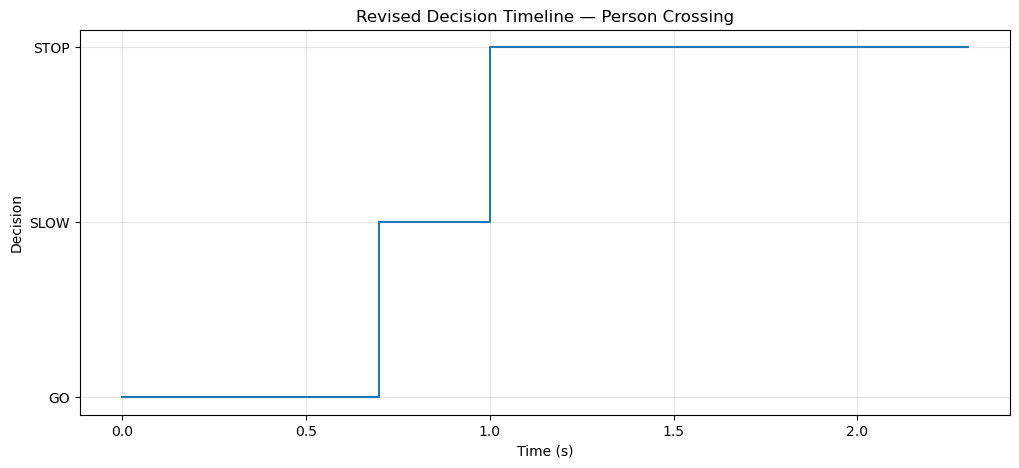

In [39]:
import cv2
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt


# ============================================================
# 1. IMAGE-BASED PERSON SCORE
# ============================================================

def get_image_person_score(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return 0.0

    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --------------------------------------------------------
    # Check row v = 235
    # --------------------------------------------------------

    v = 235
    row = img[v]

    # Brightness = R + G + B
    brightness = np.sum(row[:, :3], axis=1)

    # --------------------------------------------------------
    # Detect black pixels
    # --------------------------------------------------------

    # Black-pixel threshold = 150
    black_pixels = np.where(brightness <= 150)[0]

    # --------------------------------------------------------
    # Group nearby black pixels
    # --------------------------------------------------------

    groups = []

    if len(black_pixels) > 0:

        current_group = [black_pixels[0]]

        for i in range(1, len(black_pixels)):

            # Pixels within 3 positions are considered
            # part of the same group
            if black_pixels[i] - black_pixels[i - 1] <= 3:

                current_group.append(black_pixels[i])

            else:

                if len(current_group) >= 2:
                    groups.append(current_group)

                current_group = [black_pixels[i]]

        # Add final group
        if len(current_group) >= 2:
            groups.append(current_group)

    # --------------------------------------------------------
    # Need two groups = two legs
    # --------------------------------------------------------

    if len(groups) < 2:

        return 0.0

    # Take two largest groups
    groups = sorted(
        groups,
        key=len,
        reverse=True
    )[:2]

    # Sort groups from left → right
    groups = sorted(
        groups,
        key=lambda g: np.mean(g)
    )

    left_leg = groups[0]
    right_leg = groups[1]

    # Rightmost pixel of right leg
    right_leg_rightmost = max(right_leg)

    # --------------------------------------------------------
    # Detect RIGHT ROAD BOUNDARY
    # --------------------------------------------------------

    max_brightness = np.max(brightness)

    # Road-boundary brightness threshold = 650
    if max_brightness < 650:

        # No right boundary detected.
        # Since two legs are detected, conclude
        # that the person is on the road.

        return 1.0

    # --------------------------------------------------------
    # Find LEFT and RIGHT road boundaries
    # --------------------------------------------------------

    brightest_pixels = np.where(
        brightness == max_brightness
    )[0]

    # Leftmost brightest pixel = left boundary
    left_boundary = np.min(brightest_pixels)

    # Rightmost brightest pixel = right boundary
    right_boundary = np.max(brightest_pixels)

    # --------------------------------------------------------
    # Check minimum gap between road boundaries
    # --------------------------------------------------------

    boundary_gap = right_boundary - left_boundary

    if boundary_gap < 10:

        # Boundaries are too close to be considered
        # a valid road boundary pair.
        #
        # Therefore the right boundary is treated
        # as NOT detected.

        return 1.0

    # --------------------------------------------------------
    # Determine whether person is on road
    # --------------------------------------------------------

    if right_leg_rightmost < right_boundary:

        # Person is inside the road
        return 1.0

    else:

        # Person detected but road occupancy is uncertain
        return 0.5


# ============================================================
# 2. REVISED DECISION LOGIC
# ============================================================

def revised_decision(
    person_score,
    image_person_score,
    red_score,
    v2x_light,
    message_age
):

    # ========================================================
    # EXCEPTION:
    # IMAGE PERSON SCORE IS CHECKED FIRST
    # ========================================================

    # Strong image evidence → STOP
    if image_person_score > 0.8:

        return "STOP", "Image confirms person is on road"

    # Uncertain image evidence → SLOW
    # This is the ONLY SLOW condition checked before
    # the remaining STOP conditions.
    if 0.5 <= image_person_score <= 0.8:

        return "SLOW", (
            "Person detected but road occupancy uncertain"
        )


    # ========================================================
    # STEP 1 — ALL REMAINING STOP CONDITIONS
    # ========================================================

    # Strong secondary person evidence
    if person_score > 0.8:

        return "STOP", "High person_score"


    # --------------------------------------------------------
    # V2X DECISION
    # --------------------------------------------------------

    # Fresh V2X message
    if message_age <= 0.5:

        # Fresh RED → STOP
        if str(v2x_light).lower() == "red":

            return "STOP", "Fresh V2X reports red"


    # Stale V2X message
    else:

        # If stale V2X and strong current red evidence
        # → STOP regardless of old V2X state
        if red_score > 0.8:

            return "STOP", (
                "V2X message is stale; high red_score"
            )


    # ========================================================
    # STEP 2 — ALL SLOW CONDITIONS
    # ========================================================

    # Moderate person evidence
    if 0.5 <= person_score <= 0.8:

        return "SLOW", "Moderate person_score"


    # --------------------------------------------------------
    # V2X + RED SCORE SLOW CONDITIONS
    # --------------------------------------------------------

    # Fresh V2X
    if message_age <= 0.5:

        # Fresh GREEN but camera sees strong red evidence
        if str(v2x_light).lower() == "green":

            if red_score > 0.8:

                return "SLOW", (
                    "Fresh V2X is green but red_score is high"
                )

            if 0.5 <= red_score <= 0.8:

                return "SLOW", (
                    "Fresh V2X is green but red_score is moderate"
                )


    # Stale V2X
    else:

        # Moderate red evidence → SLOW
        if 0.5 <= red_score <= 0.8:

            return "SLOW", (
                "V2X message is stale; moderate red_score"
            )


    # Moderate red evidence in general
    if 0.5 <= red_score <= 0.8:

        return "SLOW", "Moderate red_score"


    # ========================================================
    # STEP 3 — GO
    # ========================================================

    return "GO", "No strong person/red/V2X evidence"
# ============================================================
# 3. LOAD CROSSING EVIDENCE
# ============================================================

evidence_path = "crossing_evidence.csv"

evidence = pd.read_csv(evidence_path)


# ============================================================
# 4. CALCULATE V2X MESSAGE AGE
# ============================================================

evidence["message_age"] = (
    evidence["time_s"] -
    evidence["v2x_sample_time_s"]
)


# ============================================================
# 5. LOAD PERSON-CROSSING IMAGES
# ============================================================

image_files = sorted(
    glob.glob("person_crossing/*.png"),
    key=lambda x: int(
        os.path.splitext(
            os.path.basename(x)
        )[0].split("_")[-1]
    )
)


# ============================================================
# 6. PROCESS ALL FRAMES
# ============================================================

results = []

for image_path in image_files:

    filename = os.path.basename(image_path)

    # Extract frame number
    frame_number = int(
        os.path.splitext(filename)[0].split("_")[-1]
    )

    # --------------------------------------------------------
    # Find corresponding evidence row
    # --------------------------------------------------------

    row = evidence[
        (evidence["episode"] == "person_crossing") &
        (evidence["frame"] == frame_number)
    ]

    if len(row) == 0:

        print("No evidence found for:", filename)
        continue

    row = row.iloc[0]

    # --------------------------------------------------------
    # CSV evidence
    # --------------------------------------------------------

    time_s = row["time_s"]

    person_score = row["person_score"]

    red_score = row["red_score"]

    v2x_light = row["v2x_light"]

    message_age = row["message_age"]


    # --------------------------------------------------------
    # Calculate image-based person score
    # --------------------------------------------------------

    image_person_score = get_image_person_score(
        image_path
    )


    # --------------------------------------------------------
    # Apply revised decision
    # --------------------------------------------------------

    decision, reason = revised_decision(
        person_score,
        image_person_score,
        red_score,
        v2x_light,
        message_age
    )


    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    results.append({

        "frame": frame_number,

        "time_s": time_s,

        "person_score": person_score,

        "image_person_score": image_person_score,

        "red_score": red_score,

        "v2x_light": v2x_light,

        "message_age": message_age,

        "decision": decision,

        "reason": reason
    })


# ============================================================
# 7. CREATE RESULTS DATAFRAME
# ============================================================

results_df3 = pd.DataFrame(results)


# ============================================================
# 8. PRINT FULL TIMELINE
# ============================================================

print("\n" + "=" * 120)

print(
    "PERSON CROSSING — REVISED DECISION TIMELINE"
)

print("=" * 120)

for _, r in results_df3.iterrows():

    print(
        f"Frame {int(r['frame']):02d} | "
        f"t={r['time_s']:.2f}s | "
        f"person={r['person_score']:.3f} | "
        f"image_person={r['image_person_score']:.1f} | "
        f"red={r['red_score']:.3f} | "
        f"V2X={r['v2x_light']} | "
        f"age={r['message_age']:.2f}s | "
        f"{r['decision']:4s} | "
        f"{r['reason']}"
    )


# ============================================================
# 9. PRINT COMPACT TIMELINE
# ============================================================

print("\n")
print("COMPACT TIMELINE")
print("-" * 70)

for _, r in results_df3.iterrows():

    print(
        f"Frame {int(r['frame']):02d} "
        f"(t={r['time_s']:.2f}s) → "
        f"{r['decision']}"
    )


# ============================================================
# 10. PLOT DECISION TIMELINE
# ============================================================

decision_value = {
    "GO": 0,
    "SLOW": 1,
    "STOP": 2
}

y = results_df3["decision"].map(
    decision_value
)

plt.figure(figsize=(12, 5))

plt.step(
    results_df3["time_s"],
    y,
    where="post"
)

plt.yticks(
    [0, 1, 2],
    ["GO", "SLOW", "STOP"]
)

plt.xlabel("Time (s)")
plt.ylabel("Decision")

plt.title(
    "Revised Decision Timeline — Person Crossing"
)

plt.grid(True, alpha=0.3)

plt.show()

## Stopping Timeliness Check

To determine whether the first STOP request in each episode is timely, the stopping distance is calculated using a total processing and actuation delay of **τ = 0.15 s** and a comfortable braking magnitude of **a = 0.8 m/s²**.

The approximate stopping distance is:

\[
d_{\text{stop}} = v\tau + \frac{v^2}{2a}
\]

where \(v\) is the vehicle speed in m/s.

### Procedure

For each episode:

1. The evidence corresponding to that episode is selected using the `episode` column.
2. The decision timeline is searched for the **first frame classified as STOP**.
3. If no STOP request exists, the episode is reported as having **no STOP request**.
4. For the first STOP frame, the corresponding:
   - `speed_mps`
   - `distance_to_line_m`
   
   are obtained from the crossing evidence.
5. The stopping distance is divided into:
   - **Reaction distance:** \(v\tau\)
   - **Braking distance:** \(\frac{v^2}{2a}\)
6. The available distance is compared with the required stopping distance:
   - If `distance_to_line_m ≥ d_stop`, comfortable stopping is considered **possible**.
   - If `distance_to_line_m < d_stop`, the STOP request is considered **too late for comfortable stopping**.

### Interpretation

A STOP decision is therefore evaluated not only by whether the classification is correct, but also by **when the decision is made**. A correct STOP request that arrives after the vehicle has insufficient distance to stop comfortably is treated as a timing failure.

The function is applied separately to the **Clear Green**, **Late Red**, and **Person Crossing** episodes using their respective decision DataFrames.

In [40]:
# ============================================================
# PART (d) — CHECK WHETHER STOP IS TIMELY
# ============================================================

tau = 0.15       # processing + actuation delay (s)
a = 0.8          # comfortable braking magnitude (m/s^2)


def check_first_stop(results_df, evidence_df, episode_name):

    print("\n" + "=" * 80)
    print(f"{episode_name.upper()} — FIRST STOP TIMELINESS")
    print("=" * 80)

    # --------------------------------------------------------
    # Get evidence for this episode
    # --------------------------------------------------------

    episode_data = evidence_df[
        evidence_df["episode"] == episode_name
    ].copy()

    # --------------------------------------------------------
    # Find first STOP in the decision results
    # --------------------------------------------------------

    stop_rows = results_df[
        results_df["decision"] == "STOP"
    ]

    # --------------------------------------------------------
    # No STOP request
    # --------------------------------------------------------

    if len(stop_rows) == 0:

        print("No STOP request in this episode.")
        return

    # First STOP
    first_stop = stop_rows.iloc[0]

    frame = int(first_stop["frame"])
    time_s = first_stop["time_s"]

    # --------------------------------------------------------
    # Get corresponding evidence row
    # --------------------------------------------------------

    row = episode_data[
        episode_data["frame"] == frame
    ]

    if len(row) == 0:

        print("No evidence found for first STOP frame.")
        return

    row = row.iloc[0]

    # --------------------------------------------------------
    # Required values
    # --------------------------------------------------------

    v = row["speed_mps"]
    distance_to_line = row["distance_to_line_m"]

    # --------------------------------------------------------
    # Calculate stopping distance
    # --------------------------------------------------------

    reaction_distance = v * tau

    braking_distance = (
        v ** 2
    ) / (2 * a)

    stopping_distance = (
        reaction_distance +
        braking_distance
    )

    # --------------------------------------------------------
    # Compare
    # --------------------------------------------------------

    comfortable_stop_possible = (
        distance_to_line >= stopping_distance
    )

    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------

    print(f"First STOP frame       : {frame}")
    print(f"Time                   : {time_s:.2f} s")
    print(f"Speed                  : {v:.3f} m/s")
    print(f"Distance to line       : {distance_to_line:.3f} m")
    print(f"Reaction distance      : {reaction_distance:.3f} m")
    print(f"Braking distance       : {braking_distance:.3f} m")
    print(f"Required stopping dist.: {stopping_distance:.3f} m")

    if comfortable_stop_possible:

        print(
            "Comfortable stopping  : YES"
        )

        print(
            "The available distance is sufficient "
            "for comfortable stopping."
        )

    else:

        print(
            "Comfortable stopping  : NO"
        )

        print(
            "The STOP request arrives too late for "
            "comfortable stopping."
        )


# ============================================================
# RUN FOR EACH EPISODE
# ============================================================
check_first_stop(
    results_df1,
    evidence,
    "clear_green"
)
check_first_stop(
    results_df2,
    evidence,
    "late_red"
)
check_first_stop(
    results_df3,
    evidence,
    "person_crossing"
)



CLEAR_GREEN — FIRST STOP TIMELINESS
No STOP request in this episode.

LATE_RED — FIRST STOP TIMELINESS
First STOP frame       : 9
Time                   : 0.90 s
Speed                  : 0.800 m/s
Distance to line       : 2.030 m
Reaction distance      : 0.120 m
Braking distance       : 0.400 m
Required stopping dist.: 0.520 m
Comfortable stopping  : YES
The available distance is sufficient for comfortable stopping.

PERSON_CROSSING — FIRST STOP TIMELINESS
First STOP frame       : 10
Time                   : 1.00 s
Speed                  : 0.800 m/s
Distance to line       : 1.950 m
Reaction distance      : 0.120 m
Braking distance       : 0.400 m
Required stopping dist.: 0.520 m
Comfortable stopping  : YES
The available distance is sufficient for comfortable stopping.


In [45]:
results_df1["episode"] = "clear_green"
results_df2["episode"] = "late_red"
results_df3["episode"] = "person_crossing"


PERSON CROSSING — BASELINE DECISION TIMELINE
Frame 00 | t=0.00s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 01 | t=0.10s | person=0.113 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 02 | t=0.20s | person=0.010 | image_person=0.0 | red=0.028 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 03 | t=0.30s | person=0.153 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 04 | t=0.40s | person=0.456 | image_person=0.0 | red=0.040 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 05 | t=0.50s | person=0.219 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 06 | t=0.60s | person=0.770 | image_person=0.0 | red=0.365 | V2X=green | SLOW | Moderate person_score
Frame 07 | t=0.70s | person=0.770 | image_person=0.0 | red=0.094 | V2X=green | SLOW | Moderate person_score
Frame 08 | t=0.80s

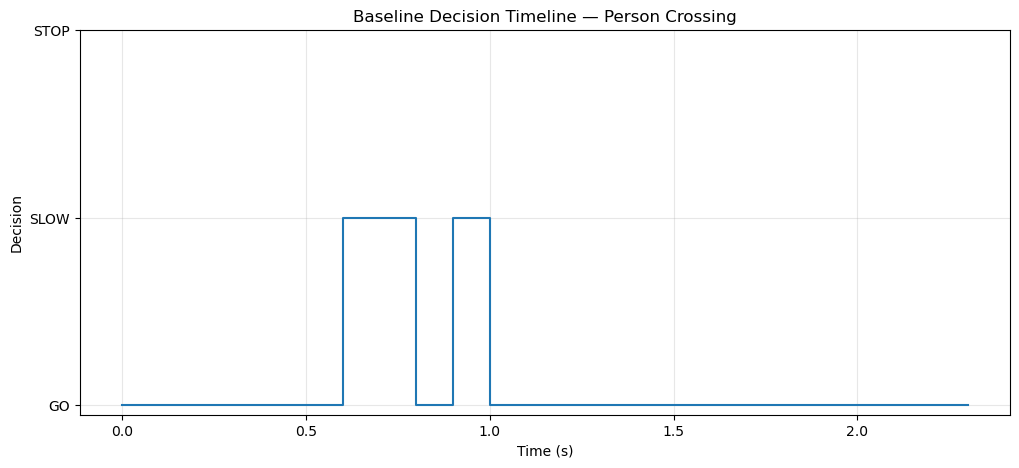


PERSON CROSSING — BASELINE DECISION TIMELINE
Frame 00 | t=0.00s | person=0.146 | image_person=0.0 | red=0.090 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 01 | t=0.10s | person=0.541 | image_person=0.0 | red=0.010 | V2X=green | SLOW | Moderate person_score
Frame 02 | t=0.20s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 03 | t=0.30s | person=0.335 | image_person=0.0 | red=0.017 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 04 | t=0.40s | person=0.078 | image_person=0.0 | red=0.108 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 05 | t=0.50s | person=0.192 | image_person=0.0 | red=0.078 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 06 | t=0.60s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 07 | t=0.70s | person=0.010 | image_person=0.0 | red=0.069 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 

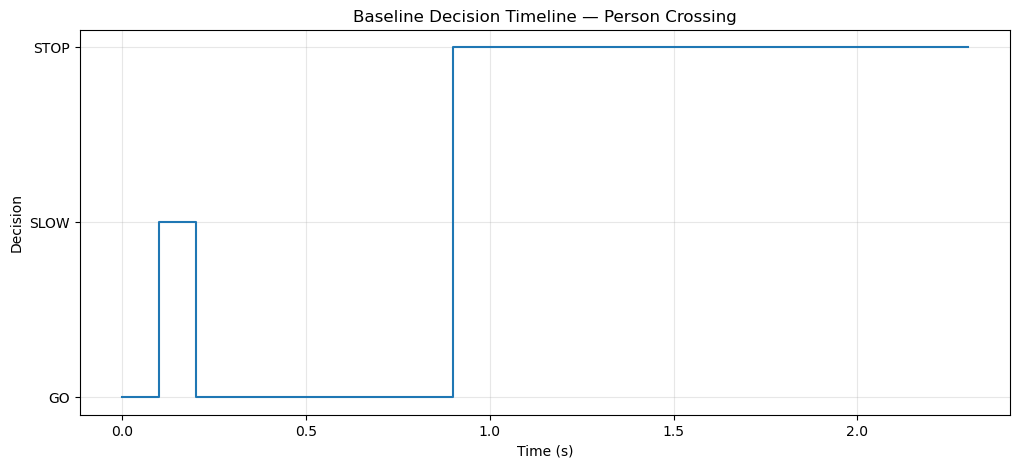


PERSON CROSSING — BASELINE DECISION TIMELINE
Frame 00 | t=0.00s | person=0.187 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 01 | t=0.10s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 02 | t=0.20s | person=0.010 | image_person=0.0 | red=0.224 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 03 | t=0.30s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 04 | t=0.40s | person=0.010 | image_person=0.0 | red=0.010 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 05 | t=0.50s | person=0.010 | image_person=0.0 | red=0.142 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 06 | t=0.60s | person=0.010 | image_person=0.0 | red=0.121 | V2X=green | GO   | No strong person/red/V2X evidence
Frame 07 | t=0.70s | person=0.824 | image_person=0.5 | red=0.010 | V2X=green | SLOW | Person detected but road occ

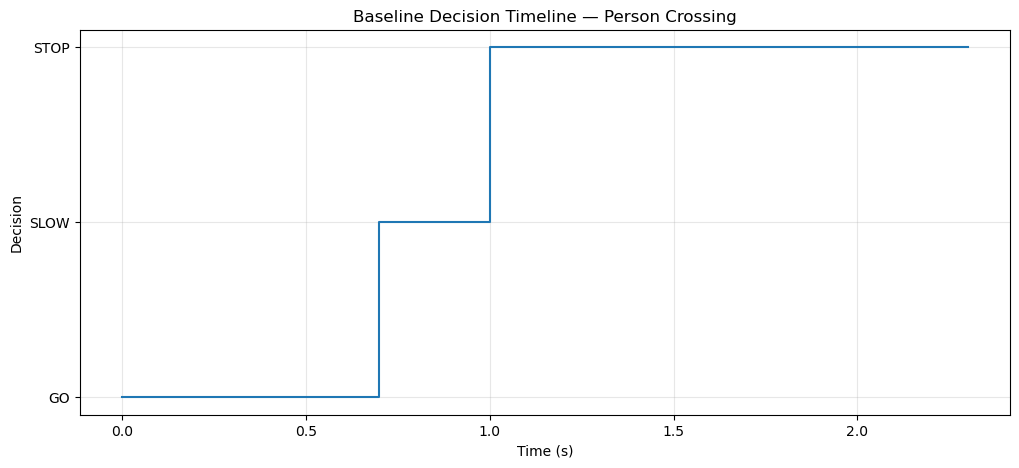

In [49]:
import cv2
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt


# ============================================================
# 1. IMAGE-BASED PERSON SCORE
# ============================================================

def get_image_person_score(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return 0.0

    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --------------------------------------------------------
    # Check row v = 235
    # --------------------------------------------------------

    v = 235
    row = img[v]

    # Brightness = R + G + B
    brightness = np.sum(row[:, :3], axis=1)

    # --------------------------------------------------------
    # Detect black pixels
    # --------------------------------------------------------

    # Black-pixel threshold = 150
    black_pixels = np.where(brightness <= 150)[0]

    # --------------------------------------------------------
    # Group nearby black pixels
    # --------------------------------------------------------

    groups = []

    if len(black_pixels) > 0:

        current_group = [black_pixels[0]]

        for i in range(1, len(black_pixels)):

            # Pixels within 3 positions are considered
            # part of the same group
            if black_pixels[i] - black_pixels[i - 1] <= 3:

                current_group.append(black_pixels[i])

            else:

                if len(current_group) >= 2:
                    groups.append(current_group)

                current_group = [black_pixels[i]]

        # Add final group
        if len(current_group) >= 2:
            groups.append(current_group)

    # --------------------------------------------------------
    # Need two groups = two legs
    # --------------------------------------------------------

    if len(groups) < 2:

        return 0.0

    # Take two largest groups
    groups = sorted(
        groups,
        key=len,
        reverse=True
    )[:2]

    # Sort groups from left → right
    groups = sorted(
        groups,
        key=lambda g: np.mean(g)
    )

    left_leg = groups[0]
    right_leg = groups[1]

    # Rightmost pixel of right leg
    right_leg_rightmost = max(right_leg)

    # --------------------------------------------------------
    # Detect RIGHT ROAD BOUNDARY
    # --------------------------------------------------------

    max_brightness = np.max(brightness)

    # Road-boundary brightness threshold = 650
    if max_brightness < 650:

        # No right boundary detected.
        # Since two legs are detected, conclude
        # that the person is on the road.

        return 1.0

    # --------------------------------------------------------
    # Find LEFT and RIGHT road boundaries
    # --------------------------------------------------------

    brightest_pixels = np.where(
        brightness == max_brightness
    )[0]

    # Leftmost brightest pixel = left boundary
    left_boundary = np.min(brightest_pixels)

    # Rightmost brightest pixel = right boundary
    right_boundary = np.max(brightest_pixels)

    # --------------------------------------------------------
    # Check minimum gap between road boundaries
    # --------------------------------------------------------

    boundary_gap = right_boundary - left_boundary

    if boundary_gap < 10:

        # Boundaries are too close to be considered
        # a valid road boundary pair.
        #
        # Therefore the right boundary is treated
        # as NOT detected.

        return 1.0

    # --------------------------------------------------------
    # Determine whether person is on road
    # --------------------------------------------------------

    if right_leg_rightmost < right_boundary:

        # Person is inside the road
        return 1.0

    else:

        # Person detected but road occupancy is uncertain
        return 0.5


# # ============================================================
# 2. BASELINE DECISION LOGIC
# ============================================================

def baseline_decision(
    person_score,
    image_person_score,
    red_score,
    v2x_light
):

  # ========================================================
    # STEP 1 — CHECK ALL STOP CONDITIONS FIRST
    # ========================================================

    # Image-based person evidence
    if image_person_score > 0.8:

        return "STOP", "Image confirms person is on road"

    if 0.5 <= image_person_score <= 0.8:

        return "SLOW", (
            "Person detected but road occupancy uncertain"
        )

    # Secondary person evidence
    if person_score > 0.8:

        return "STOP", "High person_score"

    # Red-light evidence
    if red_score > 0.8:

        return "STOP", "High red_score"

    # V2X red signal
    if str(v2x_light).lower() == "red":

        return "STOP", "V2X reports red"


    # ========================================================
    # STEP 2 — IF NO STOP, CHECK ALL SLOW CONDITIONS
    # ======================================================== 

    # Secondary person evidence
    if 0.5 <= person_score <= 0.8:

        return "SLOW", "Moderate person_score"

    # Red-light evidence
    if 0.5 <= red_score <= 0.8:

        return "SLOW", "Moderate red_score"


    # ========================================================
    # STEP 3 — OTHERWISE GO
    # ========================================================

    return "GO", "No strong person/red/V2X evidence"
# ============================================================
# 3. LOAD CROSSING EVIDENCE
# ============================================================

evidence_path = "crossing_evidence.csv"

evidence = pd.read_csv(evidence_path)


# ============================================================
# 4. LOAD PERSON-CROSSING IMAGES
# ============================================================

image_files = sorted(
    glob.glob("clear_green/*.png"),
    key=lambda x: int(
        os.path.splitext(
            os.path.basename(x)
        )[0].split("_")[-1]
    )
)


# ============================================================
# 5. PROCESS ALL FRAMES
# ============================================================

results = []

for image_path in image_files:

    filename = os.path.basename(image_path)

    # Extract frame number
    frame_number = int(
        os.path.splitext(filename)[0].split("_")[-1]
    )

    # --------------------------------------------------------
    # Find corresponding evidence row
    # --------------------------------------------------------

    row = evidence[
        (evidence["episode"] == "clear_green") &
        (evidence["frame"] == frame_number)
    ]

    if len(row) == 0:

        print("No evidence found for:", filename)
        continue

    row = row.iloc[0]

    # CSV evidence
    time_s = row["time_s"]
    person_score = row["person_score"]
    red_score = row["red_score"]
    v2x_light = row["v2x_light"]

    # --------------------------------------------------------
    # Calculate our image-based person score
    # --------------------------------------------------------

    image_person_score = get_image_person_score(
        image_path
    )

    # --------------------------------------------------------
    # Apply baseline decision
    # --------------------------------------------------------

    decision, reason = baseline_decision(
        person_score,
        image_person_score,
        red_score,
        v2x_light
    )

    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    results.append({

        "frame": frame_number,

        "time_s": time_s,

        "person_score": person_score,

        "image_person_score": image_person_score,

        "red_score": red_score,

        "v2x_light": v2x_light,

        "decision": decision,

        "reason": reason
    })


# ============================================================
# 6. CREATE RESULTS DATAFRAME
# ============================================================

results_dfb1 = pd.DataFrame(results)


# ============================================================
# 7. PRINT FULL TIMELINE
# ============================================================

print("\n" + "=" * 110)

print(
    "PERSON CROSSING — BASELINE DECISION TIMELINE"
)

print("=" * 110)

for _, r in results_dfb1.iterrows():

    print(
        f"Frame {int(r['frame']):02d} | "
        f"t={r['time_s']:.2f}s | "
        f"person={r['person_score']:.3f} | "
        f"image_person={r['image_person_score']:.1f} | "
        f"red={r['red_score']:.3f} | "
        f"V2X={r['v2x_light']} | "
        f"{r['decision']:4s} | "
        f"{r['reason']}"
    )


# ============================================================
# 8. PRINT COMPACT TIMELINE
# ============================================================

print("\n")
print("COMPACT TIMELINE")
print("-" * 60)

for _, r in results_dfb1.iterrows():

    print(
        f"Frame {int(r['frame']):02d} "
        f"(t={r['time_s']:.2f}s) → "
        f"{r['decision']}"
    )


# ============================================================
# 9. PLOT DECISION TIMELINE
# ============================================================

decision_value = {
    "GO": 0,
    "SLOW": 1,
    "STOP": 2
}

y = results_dfb1["decision"].map(
    decision_value
)

plt.figure(figsize=(12, 5))

plt.step(
    results_dfb1["time_s"],
    y,
    where="post"
)

plt.yticks(
    [0, 1, 2],
    ["GO", "SLOW", "STOP"]
)

plt.xlabel("Time (s)")
plt.ylabel("Decision")

plt.title(
    "Baseline Decision Timeline — Person Crossing"
)

plt.grid(True, alpha=0.3)

plt.show()

import cv2
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt


# ============================================================
# 1. IMAGE-BASED PERSON SCORE
# ============================================================

def get_image_person_score(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return 0.0

    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --------------------------------------------------------
    # Check row v = 235
    # --------------------------------------------------------

    v = 235
    row = img[v]

    # Brightness = R + G + B
    brightness = np.sum(row[:, :3], axis=1)

    # --------------------------------------------------------
    # Detect black pixels
    # --------------------------------------------------------

    # Black-pixel threshold = 150
    black_pixels = np.where(brightness <= 150)[0]

    # --------------------------------------------------------
    # Group nearby black pixels
    # --------------------------------------------------------

    groups = []

    if len(black_pixels) > 0:

        current_group = [black_pixels[0]]

        for i in range(1, len(black_pixels)):

            # Pixels within 3 positions are considered
            # part of the same group
            if black_pixels[i] - black_pixels[i - 1] <= 3:

                current_group.append(black_pixels[i])

            else:

                if len(current_group) >= 2:
                    groups.append(current_group)

                current_group = [black_pixels[i]]

        # Add final group
        if len(current_group) >= 2:
            groups.append(current_group)

    # --------------------------------------------------------
    # Need two groups = two legs
    # --------------------------------------------------------

    if len(groups) < 2:

        return 0.0

    # Take two largest groups
    groups = sorted(
        groups,
        key=len,
        reverse=True
    )[:2]

    # Sort groups from left → right
    groups = sorted(
        groups,
        key=lambda g: np.mean(g)
    )

    left_leg = groups[0]
    right_leg = groups[1]

    # Rightmost pixel of right leg
    right_leg_rightmost = max(right_leg)

    # --------------------------------------------------------
    # Detect RIGHT ROAD BOUNDARY
    # --------------------------------------------------------

    max_brightness = np.max(brightness)

    # Road-boundary brightness threshold = 650
    if max_brightness < 650:

        # No right boundary detected.
        # Since two legs are detected, conclude
        # that the person is on the road.

        return 1.0

    # --------------------------------------------------------
    # Find LEFT and RIGHT road boundaries
    # --------------------------------------------------------

    brightest_pixels = np.where(
        brightness == max_brightness
    )[0]

    # Leftmost brightest pixel = left boundary
    left_boundary = np.min(brightest_pixels)

    # Rightmost brightest pixel = right boundary
    right_boundary = np.max(brightest_pixels)

    # --------------------------------------------------------
    # Check minimum gap between road boundaries
    # --------------------------------------------------------

    boundary_gap = right_boundary - left_boundary

    if boundary_gap < 10:

        # Boundaries are too close to be considered
        # a valid road boundary pair.
        #
        # Therefore the right boundary is treated
        # as NOT detected.

        return 1.0

    # --------------------------------------------------------
    # Determine whether person is on road
    # --------------------------------------------------------

    if right_leg_rightmost < right_boundary:

        # Person is inside the road
        return 1.0

    else:

        # Person detected but road occupancy is uncertain
        return 0.5


# ============================================================
# 2. BASELINE DECISION LOGIC
# ============================================================

def baseline_decision(
    person_score,
    image_person_score,
    red_score,
    v2x_light
):

  # ========================================================
    # STEP 1 — CHECK ALL STOP CONDITIONS FIRST
    # ========================================================

    # Image-based person evidence
    if image_person_score > 0.8:

        return "STOP", "Image confirms person is on road"

    if 0.5 <= image_person_score <= 0.8:

        return "SLOW", (
            "Person detected but road occupancy uncertain"
        )

    # Secondary person evidence
    if person_score > 0.8:

        return "STOP", "High person_score"

    # Red-light evidence
    if red_score > 0.8:

        return "STOP", "High red_score"

    # V2X red signal
    if str(v2x_light).lower() == "red":

        return "STOP", "V2X reports red"


    # ========================================================
    # STEP 2 — IF NO STOP, CHECK ALL SLOW CONDITIONS
    # ======================================================== 

    # Secondary person evidence
    if 0.5 <= person_score <= 0.8:

        return "SLOW", "Moderate person_score"

    # Red-light evidence
    if 0.5 <= red_score <= 0.8:

        return "SLOW", "Moderate red_score"


    # ========================================================
    # STEP 3 — OTHERWISE GO
    # ========================================================

    return "GO", "No strong person/red/V2X evidence"
# ============================================================
# 3. LOAD CROSSING EVIDENCE
# ============================================================

evidence_path = "crossing_evidence.csv"

evidence = pd.read_csv(evidence_path)


# ============================================================
# 4. LOAD PERSON-CROSSING IMAGES
# ============================================================

image_files = sorted(
    glob.glob("late_red/*.png"),
    key=lambda x: int(
        os.path.splitext(
            os.path.basename(x)
        )[0].split("_")[-1]
    )
)


# ============================================================
# 5. PROCESS ALL FRAMES
# ============================================================

results = []

for image_path in image_files:

    filename = os.path.basename(image_path)

    # Extract frame number
    frame_number = int(
        os.path.splitext(filename)[0].split("_")[-1]
    )

    # --------------------------------------------------------
    # Find corresponding evidence row
    # --------------------------------------------------------

    row = evidence[
        (evidence["episode"] == "late_red") &
        (evidence["frame"] == frame_number)
    ]

    if len(row) == 0:

        print("No evidence found for:", filename)
        continue

    row = row.iloc[0]

    # CSV evidence
    time_s = row["time_s"]
    person_score = row["person_score"]
    red_score = row["red_score"]
    v2x_light = row["v2x_light"]

    # --------------------------------------------------------
    # Calculate our image-based person score
    # --------------------------------------------------------

    image_person_score = get_image_person_score(
        image_path
    )

    # --------------------------------------------------------
    # Apply baseline decision
    # --------------------------------------------------------

    decision, reason = baseline_decision(
        person_score,
        image_person_score,
        red_score,
        v2x_light
    )

    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    results.append({

        "frame": frame_number,

        "time_s": time_s,

        "person_score": person_score,

        "image_person_score": image_person_score,

        "red_score": red_score,

        "v2x_light": v2x_light,

        "decision": decision,

        "reason": reason
    })


# ============================================================
# 6. CREATE RESULTS DATAFRAME
# ============================================================

results_dfb2 = pd.DataFrame(results)


# ============================================================
# 7. PRINT FULL TIMELINE
# ============================================================

print("\n" + "=" * 110)

print(
    "PERSON CROSSING — BASELINE DECISION TIMELINE"
)

print("=" * 110)

for _, r in results_dfb2.iterrows():

    print(
        f"Frame {int(r['frame']):02d} | "
        f"t={r['time_s']:.2f}s | "
        f"person={r['person_score']:.3f} | "
        f"image_person={r['image_person_score']:.1f} | "
        f"red={r['red_score']:.3f} | "
        f"V2X={r['v2x_light']} | "
        f"{r['decision']:4s} | "
        f"{r['reason']}"
    )


# ============================================================
# 8. PRINT COMPACT TIMELINE
# ============================================================

print("\n")
print("COMPACT TIMELINE")
print("-" * 60)

for _, r in results_dfb2.iterrows():

    print(
        f"Frame {int(r['frame']):02d} "
        f"(t={r['time_s']:.2f}s) → "
        f"{r['decision']}"
    )


# ============================================================
# 9. PLOT DECISION TIMELINE
# ============================================================

decision_value = {
    "GO": 0,
    "SLOW": 1,
    "STOP": 2
}

y = results_dfb2["decision"].map(
    decision_value
)

plt.figure(figsize=(12, 5))

plt.step(
    results_dfb2["time_s"],
    y,
    where="post"
)

plt.yticks(
    [0, 1, 2],
    ["GO", "SLOW", "STOP"]
)

plt.xlabel("Time (s)")
plt.ylabel("Decision")

plt.title(
    "Baseline Decision Timeline — Person Crossing"
)

plt.grid(True, alpha=0.3)

plt.show()

import cv2
import numpy as np
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt


# ============================================================
# 1. IMAGE-BASED PERSON SCORE
# ============================================================

def get_image_person_score(image_path):

    img = cv2.imread(image_path)

    if img is None:
        return 0.0

    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --------------------------------------------------------
    # Check row v = 235
    # --------------------------------------------------------

    v = 235
    row = img[v]

    # Brightness = R + G + B
    brightness = np.sum(row[:, :3], axis=1)

    # --------------------------------------------------------
    # Detect black pixels
    # --------------------------------------------------------

    # Black-pixel threshold = 150
    black_pixels = np.where(brightness <= 150)[0]

    # --------------------------------------------------------
    # Group nearby black pixels
    # --------------------------------------------------------

    groups = []

    if len(black_pixels) > 0:

        current_group = [black_pixels[0]]

        for i in range(1, len(black_pixels)):

            # Pixels within 3 positions are considered
            # part of the same group
            if black_pixels[i] - black_pixels[i - 1] <= 3:

                current_group.append(black_pixels[i])

            else:

                if len(current_group) >= 2:
                    groups.append(current_group)

                current_group = [black_pixels[i]]

        # Add final group
        if len(current_group) >= 2:
            groups.append(current_group)

    # --------------------------------------------------------
    # Need two groups = two legs
    # --------------------------------------------------------

    if len(groups) < 2:

        return 0.0

    # Take two largest groups
    groups = sorted(
        groups,
        key=len,
        reverse=True
    )[:2]

    # Sort groups from left → right
    groups = sorted(
        groups,
        key=lambda g: np.mean(g)
    )

    left_leg = groups[0]
    right_leg = groups[1]

    # Rightmost pixel of right leg
    right_leg_rightmost = max(right_leg)

    # --------------------------------------------------------
    # Detect RIGHT ROAD BOUNDARY
    # --------------------------------------------------------

    max_brightness = np.max(brightness)

    # Road-boundary brightness threshold = 650
    if max_brightness < 650:

        # No right boundary detected.
        # Since two legs are detected, conclude
        # that the person is on the road.

        return 1.0

    # --------------------------------------------------------
    # Find LEFT and RIGHT road boundaries
    # --------------------------------------------------------

    brightest_pixels = np.where(
        brightness == max_brightness
    )[0]

    # Leftmost brightest pixel = left boundary
    left_boundary = np.min(brightest_pixels)

    # Rightmost brightest pixel = right boundary
    right_boundary = np.max(brightest_pixels)

    # --------------------------------------------------------
    # Check minimum gap between road boundaries
    # --------------------------------------------------------

    boundary_gap = right_boundary - left_boundary

    if boundary_gap < 10:

        # Boundaries are too close to be considered
        # a valid road boundary pair.
        #
        # Therefore the right boundary is treated
        # as NOT detected.

        return 1.0

    # --------------------------------------------------------
    # Determine whether person is on road
    # --------------------------------------------------------

    if right_leg_rightmost < right_boundary:

        # Person is inside the road
        return 1.0

    else:

        # Person detected but road occupancy is uncertain
        return 0.5


# ============================================================
# 2. BASELINE DECISION LOGIC
# ============================================================

def baseline_decision(
    person_score,
    image_person_score,
    red_score,
    v2x_light
):

    # ========================================================
    # STEP 1 — CHECK ALL STOP CONDITIONS FIRST
    # ========================================================

    # Image-based person evidence
    if image_person_score > 0.8:

        return "STOP", "Image confirms person is on road"

    if 0.5 <= image_person_score <= 0.8:

        return "SLOW", (
            "Person detected but road occupancy uncertain"
        )

    # Secondary person evidence
    if person_score > 0.8:

        return "STOP", "High person_score"

    # Red-light evidence
    if red_score > 0.8:

        return "STOP", "High red_score"

    # V2X red signal
    if str(v2x_light).lower() == "red":

        return "STOP", "V2X reports red"


    # ========================================================
    # STEP 2 — IF NO STOP, CHECK ALL SLOW CONDITIONS
    # ======================================================== 

    # Secondary person evidence
    if 0.5 <= person_score <= 0.8:

        return "SLOW", "Moderate person_score"

    # Red-light evidence
    if 0.5 <= red_score <= 0.8:

        return "SLOW", "Moderate red_score"


    # ========================================================
    # STEP 3 — OTHERWISE GO
    # ========================================================

    return "GO", "No strong person/red/V2X evidence"
# ============================================================
# 3. LOAD CROSSING EVIDENCE
# ============================================================

evidence_path = "crossing_evidence.csv"

evidence = pd.read_csv(evidence_path)


# ============================================================
# 4. LOAD PERSON-CROSSING IMAGES
# ============================================================

image_files = sorted(
    glob.glob("person_crossing/*.png"),
    key=lambda x: int(
        os.path.splitext(
            os.path.basename(x)
        )[0].split("_")[-1]
    )
)


# ============================================================
# 5. PROCESS ALL FRAMES
# ============================================================

results = []

for image_path in image_files:

    filename = os.path.basename(image_path)

    # Extract frame number
    frame_number = int(
        os.path.splitext(filename)[0].split("_")[-1]
    )

    # --------------------------------------------------------
    # Find corresponding evidence row
    # --------------------------------------------------------

    row = evidence[
        (evidence["episode"] == "person_crossing") &
        (evidence["frame"] == frame_number)
    ]

    if len(row) == 0:

        print("No evidence found for:", filename)
        continue

    row = row.iloc[0]

    # CSV evidence
    time_s = row["time_s"]
    person_score = row["person_score"]
    red_score = row["red_score"]
    v2x_light = row["v2x_light"]

    # --------------------------------------------------------
    # Calculate our image-based person score
    # --------------------------------------------------------

    image_person_score = get_image_person_score(
        image_path
    )

    # --------------------------------------------------------
    # Apply baseline decision
    # --------------------------------------------------------

    decision, reason = baseline_decision(
        person_score,
        image_person_score,
        red_score,
        v2x_light
    )

    # --------------------------------------------------------
    # Store result
    # --------------------------------------------------------

    results.append({

        "frame": frame_number,

        "time_s": time_s,

        "person_score": person_score,

        "image_person_score": image_person_score,

        "red_score": red_score,

        "v2x_light": v2x_light,

        "decision": decision,

        "reason": reason
    })


# ============================================================
# 6. CREATE RESULTS DATAFRAME
# ============================================================

results_dfb3= pd.DataFrame(results)


# ============================================================
# 7. PRINT FULL TIMELINE
# ============================================================

print("\n" + "=" * 110)

print(
    "PERSON CROSSING — BASELINE DECISION TIMELINE"
)

print("=" * 110)

for _, r in results_dfb3.iterrows():

    print(
        f"Frame {int(r['frame']):02d} | "
        f"t={r['time_s']:.2f}s | "
        f"person={r['person_score']:.3f} | "
        f"image_person={r['image_person_score']:.1f} | "
        f"red={r['red_score']:.3f} | "
        f"V2X={r['v2x_light']} | "
        f"{r['decision']:4s} | "
        f"{r['reason']}"
    )


# ============================================================
# 8. PRINT COMPACT TIMELINE
# ============================================================

print("\n")
print("COMPACT TIMELINE")
print("-" * 60)

for _, r in results_dfb3.iterrows():

    print(
        f"Frame {int(r['frame']):02d} "
        f"(t={r['time_s']:.2f}s) → "
        f"{r['decision']}"
    )


# ============================================================
# 9. PLOT DECISION TIMELINE
# ============================================================

decision_value = {
    "GO": 0,
    "SLOW": 1,
    "STOP": 2
}

y = results_dfb3["decision"].map(
    decision_value
)

plt.figure(figsize=(12, 5))

plt.step(
    results_dfb3["time_s"],
    y,
    where="post"
)

plt.yticks(
    [0, 1, 2],
    ["GO", "SLOW", "STOP"]
)

plt.xlabel("Time (s)")
plt.ylabel("Decision")

plt.title(
    "Baseline Decision Timeline — Person Crossing"
)

plt.grid(True, alpha=0.3)

plt.show()


## Part (e) — Testing Uncertainty

The purpose of this part is to test how robust the baseline and revised decision systems are when the perception scores are noisy. Since `person_score` and `red_score` are not perfectly reliable in a real autonomous vehicle, small changes in these scores can potentially change the final decision.

### 1. Random perturbation

A fixed random seed of **42** is used so that the experiment is reproducible. For each trial, Gaussian noise with standard deviation `0.05` is independently generated for `person_score` and `red_score`.

The perturbed scores are clipped to the range `[0, 1]`.

The experiment is repeated for **20 trials**. Therefore, every trial represents a different possible realization of sensor/perception uncertainty.

### 2. Same perturbation for baseline and revised systems

For a particular trial, the **same perturbed scores are given to both the baseline and revised decision rules**. This makes the comparison fair because both systems receive exactly the same noisy evidence.

Each trial evaluates all:

- 24 `clear_green` frames
- 24 `late_red` frames
- 24 `person_crossing` frames

Therefore:

**20 trials × 72 frames = 1,440 frame-level evaluations per decision system.**

### 3. V2X message age

The code calculates the age of each V2X message as:

```text
message_age = time_s − v2x_sample_time_s
```

This allows the revised decision rule to distinguish between fresh and stale V2X information instead of treating an old signal state as current.

### 4. Evaluation using the reference data

The `crossing_reference.csv` file is used **only for evaluation**, not for making decisions.

For each frame, the system output is compared with `stop_required` from the reference.

Only an explicit **`STOP`** decision is counted as STOP.

- `STOP` → counted as STOP
- `SLOW` → **not** counted as STOP
- `GO` → not counted as STOP

Thus, if STOP is required but the system outputs SLOW, it is counted as a **missed STOP**.

### 5. Performance measures

For both baseline and revised systems, the code calculates:

**Missed STOP frames**

Frames where the reference requires STOP but the system does not output STOP.

**Unnecessary STOP frames**

Frames where the reference does not require STOP but the system outputs STOP.

This allows the safety performance of the two decision rules to be compared under uncertainty.

### 6. STOP response delay

For episodes that require a STOP, the code identifies:

- the first frame where STOP is required according to the reference
- the first frame where the system actually outputs `STOP`

The response delay is calculated as:

```text
Response delay =
First system STOP time − First required STOP time
```

Importantly, **SLOW is not treated as the first STOP**.

If an episode does not require STOP, its response delay is reported as not applicable.

### 7. Original baseline error analysis

Finally, the code separately examines the **original, unperturbed baseline** to identify:

- a false alarm, where the baseline outputs STOP although STOP is not required
- a dangerous delay, where STOP is required but the baseline issues STOP only later

The corresponding frame, time, evidence scores, V2X state, and decision reason are printed so that the cause of the error can be examined.

### Overall methodology

```text
72 original frames
        ↓
Add Gaussian noise
        ↓
   Trial 1 ─────────┐
   Trial 2          │
   ...              ├──→ Baseline + Revised
   Trial 20 ────────┘
        ↓
Compare with reference
        ↓
Missed STOP
Unnecessary STOP
STOP response delay
        ↓
Compare baseline vs revised
```

**In summary:** the code tests whether the decision logic remains reliable when perception scores are slightly perturbed, while ensuring that both baseline and revised systems are tested under exactly the same uncertainty conditions.

In [55]:
# ============================================================
# PART (e) — UNCERTAINTY TESTING
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os


# ============================================================
# 1. SETTINGS
# ============================================================

RANDOM_SEED = 42
N_TRIALS = 20
NOISE_STD = 0.05

rng = np.random.default_rng(RANDOM_SEED)


# ============================================================
# 2. LOAD ORIGINAL EVIDENCE
# ============================================================

evidence = pd.read_csv(
    "crossing_evidence.csv"
)

reference = pd.read_csv(
    "crossing_reference.csv"
)


# ============================================================
# 3. CALCULATE V2X MESSAGE AGE
# ============================================================

evidence["message_age"] = (
    evidence["time_s"]
    - evidence["v2x_sample_time_s"]
)


# ============================================================
# 4. GET IMAGE PERSON SCORES
# ============================================================
# results_dfb1 = baseline results for clear_green
# results_dfb2 = baseline results for late_red
# results_dfb3 = baseline results for person_crossing
#
# These are used only to obtain image_person_score.
# ============================================================

image_scores_1 = results_dfb1[
    [
        "frame",
        "image_person_score"
    ]
].copy()

image_scores_1["episode"] = "clear_green"


image_scores_2 = results_dfb2[
    [
        "frame",
        "image_person_score"
    ]
].copy()

image_scores_2["episode"] = "late_red"


image_scores_3 = results_dfb3[
    [
        "frame",
        "image_person_score"
    ]
].copy()

image_scores_3["episode"] = "person_crossing"


# ============================================================
# 5. COMBINE IMAGE SCORES
# ============================================================

image_scores = pd.concat(
    [
        image_scores_1,
        image_scores_2,
        image_scores_3
    ],
    ignore_index=True
)


# ============================================================
# 6. COMBINE WITH ORIGINAL EVIDENCE
# ============================================================

episodes = evidence.merge(

    image_scores,

    on=[
        "episode",
        "frame"
    ],

    how="left"
)


# ============================================================
# 7. CHECK IMAGE SCORES
# ============================================================

if episodes["image_person_score"].isna().any():

    print(
        "WARNING: Some frames have no image_person_score."
    )

else:

    print(
        "All frames have image_person_score."
    )


# ============================================================
# 8. CONVERT REFERENCE STOP VALUES TO BOOLEAN
# ============================================================

def is_stop_required(value):

    if isinstance(value, str):

        value = value.strip().lower()

        if value in [
            "true",
            "yes",
            "stop",
            "1"
        ]:

            return True

        if value in [
            "false",
            "no",
            "go",
            "0"
        ]:

            return False

    return bool(value)


reference["stop_required_bool"] = (
    reference["stop_required"]
    .apply(is_stop_required)
)


# ============================================================
# 9. RUN ONE UNCERTAINTY TRIAL
# ============================================================

def run_trial(
    base_df,
    episode_name,
    rng
):

    df = base_df.copy()


    # ========================================================
    # GENERATE RANDOM PERTURBATION
    # ========================================================
    # SAME perturbation is used for baseline and revised.
    # ========================================================

    person_noise = rng.normal(
        0,
        NOISE_STD,
        len(df)
    )

    red_noise = rng.normal(
        0,
        NOISE_STD,
        len(df)
    )


    # ========================================================
    # PERTURB PERSON SCORE
    # ========================================================

    df["perturbed_person_score"] = np.clip(

        df["person_score"]
        + person_noise,

        0,
        1
    )


    # ========================================================
    # PERTURB RED SCORE
    # ========================================================

    df["perturbed_red_score"] = np.clip(

        df["red_score"]
        + red_noise,

        0,
        1
    )


    # ========================================================
    # DECISION STORAGE
    # ========================================================

    baseline_decisions = []
    baseline_reasons = []

    revised_decisions = []
    revised_reasons = []


    # ========================================================
    # PROCESS EVERY FRAME
    # ========================================================

    for _, row in df.iterrows():

        person_score = (
            row["perturbed_person_score"]
        )

        red_score = (
            row["perturbed_red_score"]
        )

        image_person_score = (
            row["image_person_score"]
        )

        v2x_light = (
            row["v2x_light"]
        )

        message_age = (
            row["message_age"]
        )


        # ====================================================
        # BASELINE DECISION
        # ====================================================

        baseline_value, baseline_reason = (

            baseline_decision(

                person_score,

                image_person_score,

                red_score,

                v2x_light
            )
        )


        # ====================================================
        # REVISED DECISION
        # ====================================================

        revised_value, revised_reason = (

            revised_decision(

                person_score,

                image_person_score,

                red_score,

                v2x_light,

                message_age
            )
        )


        # ----------------------------------------------------
        # Store
        # ----------------------------------------------------

        baseline_decisions.append(
            baseline_value
        )

        baseline_reasons.append(
            baseline_reason
        )

        revised_decisions.append(
            revised_value
        )

        revised_reasons.append(
            revised_reason
        )


    # ========================================================
    # ADD DECISIONS
    # ========================================================

    df["baseline_decision"] = (
        baseline_decisions
    )

    df["baseline_reason"] = (
        baseline_reasons
    )

    df["revised_decision"] = (
        revised_decisions
    )

    df["revised_reason"] = (
        revised_reasons
    )


    return df


# ============================================================
# 10. SCORE ONE TRIAL
# ============================================================

def score_trial(

    trial_df,

    episode_name,

    reference_df

):


    # ========================================================
    # REFERENCE FOR THIS EPISODE
    # ========================================================

    ref = reference_df[
        reference_df["episode"]
        == episode_name
    ].copy()


    # ========================================================
    # REFERENCE USED ONLY FOR SCORING
    # ========================================================

    merged = trial_df.merge(

        ref[
            [
                "episode",
                "frame",
                "stop_required_bool"
            ]
        ],

        on=[
            "episode",
            "frame"
        ],

        how="left"
    )


    # ========================================================
    # BASELINE STOP
    # ========================================================
    # ONLY EXACT "STOP" COUNTS.
    # SLOW IS NOT STOP.
    # ========================================================

    baseline_stop = (

        merged["baseline_decision"]
        == "STOP"
    )


    required_stop = (

        merged["stop_required_bool"]
        == True
    )


    # ========================================================
    # MISSED STOP — BASELINE
    # ========================================================
    # Reference requires STOP but system did NOT say STOP.
    # Therefore SLOW and GO are both missed STOPs.
    # ========================================================

    missed_baseline = (

        required_stop
        & ~baseline_stop
    )


    # ========================================================
    # UNNECESSARY STOP — BASELINE
    # ========================================================
    # STOP was NOT required but system explicitly said STOP.
    # SLOW is NOT counted.
    # ========================================================

    unnecessary_baseline = (

        ~required_stop
        & baseline_stop
    )


    # ========================================================
    # REVISED STOP
    # ========================================================
    # ONLY EXACT "STOP" COUNTS.
    # ========================================================

    revised_stop = (

        merged["revised_decision"]
        == "STOP"
    )


    # ========================================================
    # MISSED STOP — REVISED
    # ========================================================

    missed_revised = (

        required_stop
        & ~revised_stop
    )


    # ========================================================
    # UNNECESSARY STOP — REVISED
    # ========================================================

    unnecessary_revised = (

        ~required_stop
        & revised_stop
    )


    # ========================================================
    # FIRST REQUIRED STOP
    # ========================================================

    required_rows = merged[

        merged["stop_required_bool"]
        == True

    ].sort_values("frame")


    if len(required_rows) == 0:

        first_required_time = None

    else:

        first_required_time = (
            required_rows.iloc[0]["time_s"]
        )


    # ========================================================
    # FIRST BASELINE STOP
    # ========================================================
    # IMPORTANT:
    # SLOW IS NOT INCLUDED.
    # ========================================================

    baseline_stop_rows = merged[

        merged["baseline_decision"]
        == "STOP"

    ].sort_values("frame")


    if len(baseline_stop_rows) == 0:

        baseline_first_stop_time = None
        baseline_delay = None

    else:

        baseline_first_stop_time = (
            baseline_stop_rows.iloc[0]["time_s"]
        )

        if first_required_time is None:

            baseline_delay = None

        else:

            baseline_delay = (

                baseline_first_stop_time
                - first_required_time

            )


    # ========================================================
    # FIRST REVISED STOP
    # ========================================================
    # IMPORTANT:
    # SLOW IS NOT INCLUDED.
    # ========================================================

    revised_stop_rows = merged[

        merged["revised_decision"]
        == "STOP"

    ].sort_values("frame")


    if len(revised_stop_rows) == 0:

        revised_first_stop_time = None
        revised_delay = None

    else:

        revised_first_stop_time = (
            revised_stop_rows.iloc[0]["time_s"]
        )

        if first_required_time is None:

            revised_delay = None

        else:

            revised_delay = (

                revised_first_stop_time
                - first_required_time

            )


    # ========================================================
    # RETURN
    # ========================================================

    return {

        "episode": episode_name,

        "missed_baseline":
            int(missed_baseline.sum()),

        "unnecessary_baseline":
            int(unnecessary_baseline.sum()),

        "missed_revised":
            int(missed_revised.sum()),

        "unnecessary_revised":
            int(unnecessary_revised.sum()),

        "first_required_time":
            first_required_time,

        "baseline_first_stop":
            baseline_first_stop_time,

        "baseline_delay":
            baseline_delay,

        "revised_first_stop":
            revised_first_stop_time,

        "revised_delay":
            revised_delay
    }


# ============================================================
# 11. RUN 20 TRIALS
# ============================================================

all_scores = []

all_trial_outputs = []


for trial in range(

    1,

    N_TRIALS + 1

):

    print(
        f"\nRunning trial "
        f"{trial}/{N_TRIALS}"
    )


    for episode_name in [

        "clear_green",

        "late_red",

        "person_crossing"

    ]:


        # ----------------------------------------------------
        # ORIGINAL EVIDENCE
        # ----------------------------------------------------

        base_df = episodes[

            episodes["episode"]
            == episode_name

        ].copy()


        # ----------------------------------------------------
        # SAME PERTURBATION FOR BOTH SYSTEMS
        # ----------------------------------------------------

        trial_df = run_trial(

            base_df,

            episode_name,

            rng

        )


        trial_df["trial"] = trial


        all_trial_outputs.append(
            trial_df
        )


        # ----------------------------------------------------
        # SCORE
        # ----------------------------------------------------

        score = score_trial(

            trial_df,

            episode_name,

            reference

        )


        score["trial"] = trial


        all_scores.append(
            score
        )


# ============================================================
# 12. RESULTS DATAFRAME
# ============================================================

scores_df = pd.DataFrame(
    all_scores
)


# ============================================================
# 13. PRINT ALL TRIAL RESULTS
# ============================================================

print("\n")

print("=" * 120)

print(
    "20-TRIAL UNCERTAINTY RESULTS"
)

print("=" * 120)


print(

    scores_df[

        [
            "trial",
            "episode",

            "missed_baseline",
            "missed_revised",

            "unnecessary_baseline",
            "unnecessary_revised",

            "baseline_delay",
            "revised_delay"
        ]

    ].to_string(
        index=False
    )
)


# ============================================================
# 14. AVERAGE PERFORMANCE
# ============================================================

summary = (

    scores_df

    .groupby("episode")

    .agg(

        baseline_missed_STOP=(
            "missed_baseline",
            "mean"
        ),

        revised_missed_STOP=(
            "missed_revised",
            "mean"
        ),

        baseline_unnecessary_STOP=(
            "unnecessary_baseline",
            "mean"
        ),

        revised_unnecessary_STOP=(
            "unnecessary_revised",
            "mean"
        ),

        baseline_response_delay=(
            "baseline_delay",
            "mean"
        ),

        revised_response_delay=(
            "revised_delay",
            "mean"
        )

    )

    .reset_index()
)


# ============================================================
# 15. PRINT SUMMARY
# ============================================================

print("\n")

print("=" * 120)

print(
    "AVERAGE PERFORMANCE OVER 20 TRIALS"
)

print("=" * 120)


print(
    summary.to_string(
        index=False
    )
)


# ============================================================
# 16. TOTAL PERFORMANCE
# ============================================================

print("\n")

print("=" * 120)

print(
    "TOTAL PERFORMANCE OVER 20 TRIALS"
)

print("=" * 120)


print(
    "Baseline missed STOP frames      :",
    scores_df[
        "missed_baseline"
    ].sum()
)


print(
    "Revised missed STOP frames       :",
    scores_df[
        "missed_revised"
    ].sum()
)


print(
    "Baseline unnecessary STOP frames :",
    scores_df[
        "unnecessary_baseline"
    ].sum()
)


print(
    "Revised unnecessary STOP frames  :",
    scores_df[
        "unnecessary_revised"
    ].sum()
)


# ============================================================
# 17. FIND ONE FALSE ALARM
#     ORIGINAL BASELINE — NO PERTURBATION
# ============================================================

print("\n")

print("=" * 120)

print(
    "FALSE ALARM — ORIGINAL BASELINE"
)

print("=" * 120)


false_alarm_found = False


for episode_name in [

    "clear_green",

    "late_red",

    "person_crossing"

]:

    # --------------------------------------------------------
    # Get original baseline results
    # --------------------------------------------------------

    if episode_name == "clear_green":

        base_df = results_dfb1.copy()

    elif episode_name == "late_red":

        base_df = results_dfb2.copy()

    else:

        base_df = results_dfb3.copy()


    base_df["episode"] = episode_name


    ref = reference[

        reference["episode"]
        == episode_name

    ].copy()


    original = base_df.merge(

        ref[
            [
                "episode",
                "frame",
                "stop_required_bool"
            ]
        ],

        on=[
            "episode",
            "frame"
        ],

        how="left"
    )


    # ONLY EXACT STOP
    false_alarm = original[

        (original["decision"] == "STOP")
        &
        (original["stop_required_bool"] == False)

    ]


    if len(false_alarm) > 0:

        row = false_alarm.iloc[0]


        print(
            f"Episode       : {episode_name}"
        )

        print(
            f"Frame         : "
            f"{int(row['frame'])}"
        )

        print(
            f"Time          : "
            f"{row['time_s']:.2f} s"
        )

        print(
            f"person_score  : "
            f"{row['person_score']:.3f}"
        )

        print(
            f"red_score     : "
            f"{row['red_score']:.3f}"
        )

        print(
            f"V2X           : "
            f"{row['v2x_light']}"
        )

        print(
            f"Decision      : "
            f"{row['decision']}"
        )

        if "reason" in row.index:

            print(
                f"Reason        : "
                f"{row['reason']}"
            )


        false_alarm_found = True

        break


if not false_alarm_found:

    print(
        "No false alarm found "
        "in the original baseline."
    )


# ============================================================
# 18. FIND ONE DANGEROUS DELAY
#     ORIGINAL BASELINE — NO PERTURBATION
# ============================================================

print("\n")

print("=" * 120)

print(
    "DANGEROUS DELAY — ORIGINAL BASELINE"
)

print("=" * 120)


dangerous_delay_found = False


for episode_name in [

    "clear_green",

    "late_red",

    "person_crossing"

]:

    # --------------------------------------------------------
    # Get original baseline results
    # --------------------------------------------------------

    if episode_name == "clear_green":

        base_df = results_dfb1.copy()

    elif episode_name == "late_red":

        base_df = results_dfb2.copy()

    else:

        base_df = results_dfb3.copy()


    base_df["episode"] = episode_name


    ref = reference[

        reference["episode"]
        == episode_name

    ].copy()


    original = base_df.merge(

        ref[
            [
                "episode",
                "frame",
                "stop_required_bool"
            ]
        ],

        on=[
            "episode",
            "frame"
        ],

        how="left"
    )


    # --------------------------------------------------------
    # First required STOP
    # --------------------------------------------------------

    required = original[

        original["stop_required_bool"] == True

    ].sort_values("frame")


    if len(required) == 0:

        continue


    first_required = required.iloc[0]


    # --------------------------------------------------------
    # FIRST ACTUAL STOP ONLY
    # --------------------------------------------------------

    first_stop = original[

        original["decision"] == "STOP"

    ].sort_values("frame")


    # --------------------------------------------------------
    # NO STOP
    # --------------------------------------------------------

    if len(first_stop) == 0:

        print(
            f"Episode       : "
            f"{episode_name}"
        )

        print(
            "Dangerous delay: NO STOP REQUEST"
        )

        print(
            f"First required STOP time: "
            f"{first_required['time_s']:.2f} s"
        )


        dangerous_delay_found = True

        break


    first_stop = first_stop.iloc[0]


    # --------------------------------------------------------
    # Calculate delay
    # --------------------------------------------------------

    delay = (

        first_stop["time_s"]
        - first_required["time_s"]

    )


    # --------------------------------------------------------
    # Positive delay
    # --------------------------------------------------------

    if delay > 0:

        print(
            f"Episode       : "
            f"{episode_name}"
        )

        print(
            f"First required STOP frame : "
            f"{int(first_required['frame'])}"
        )

        print(
            f"First required STOP time   : "
            f"{first_required['time_s']:.2f} s"
        )

        print(
            f"First system STOP frame    : "
            f"{int(first_stop['frame'])}"
        )

        print(
            f"First system STOP time     : "
            f"{first_stop['time_s']:.2f} s"
        )

        print(
            f"Response delay             : "
            f"{delay:.2f} s"
        )

        if "reason" in first_stop.index:

            print(
                f"Reason for STOP            : "
                f"{first_stop['reason']}"
            )


        dangerous_delay_found = True

        break


if not dangerous_delay_found:

    print(
        "No dangerous delay found "
        "in the original baseline."
    )

All frames have image_person_score.

Running trial 1/20

Running trial 2/20

Running trial 3/20

Running trial 4/20

Running trial 5/20

Running trial 6/20

Running trial 7/20

Running trial 8/20

Running trial 9/20

Running trial 10/20

Running trial 11/20

Running trial 12/20

Running trial 13/20

Running trial 14/20

Running trial 15/20

Running trial 16/20

Running trial 17/20

Running trial 18/20

Running trial 19/20

Running trial 20/20


20-TRIAL UNCERTAINTY RESULTS
 trial         episode  missed_baseline  missed_revised  unnecessary_baseline  unnecessary_revised  baseline_delay  revised_delay
     1     clear_green                0               0                     0                    0             NaN            NaN
     1        late_red                0               0                     0                    0             0.0            0.0
     1 person_crossing                0               0                     0                    0             0.0            0.0
  